# Statistical Analysis of Diet Efficacy
### "A 6-Week Weight Loss Study"
* #### Shapiro-Wilk (goodness-of-fit test for normality)
* #### Mann-Whitney U (nonparametric test for comparing two independent groups) vs. t-test
* #### Wilcoxon (nonparametric test for comparing two paired groups) vs. Paired t-test

**Project Overview**

**Introduction**
This project focuses on analyzing the effectiveness of three different dietary programs over a six-week period. Using a dataset containing physiological measurements (age, height, gender) and body weight records, the study employs both exploratory data analysis (EDA) and rigorous statistical testing to determine the impact of these interventions on weight loss.

**Objective**

The primary goal of this analysis is to evaluate whether the applied diets lead to a statistically significant reduction in body weight. To ensure the reliability of the results, the project aims to:

* Perform comprehensive data cleaning and descriptive statistics.

* Assess the normality of data distribution using the **Shapiro-Wilk test**.

* Dilemma between using the **Mann–Whitney U test** vs. the **t-test**, and the **Wilcoxon test** vs. the **paired t-test**.

* Identify which diet type, if any, produces the most significant weight-loss results.

# Import Libraries

In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, ttest_ind, ttest_rel, wilcoxon

In [226]:
df = pd.read_csv('weight.csv')

In [227]:
df.sample(5)

,Person,gender,Age,Height,pre.weight,Diet,weight6weeks
63,49,1,37,198,79,2,71.1
6,5,0,50,170,65,1,62.2
62,48,1,40,171,79,2,72.9
61,47,1,44,163,79,2,73.6
34,56,0,36,160,66,3,58.2


In [228]:
df.describe()

,Person,Age,Height,pre.weight,Diet,weight6weeks
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,39.500000,39.153846,170.820513,72.525641,2.038462,68.680769
std,22.660538,9.815277,11.276621,8.723344,0.812920,8.924504
min,1.000000,16.000000,141.000000,58.000000,1.000000,53.000000
25%,20.250000,32.250000,164.250000,66.000000,1.000000,61.850000
50%,39.500000,39.000000,169.500000,72.000000,2.000000,68.950000
75%,58.750000,46.750000,174.750000,78.000000,3.000000,73.825000
max,78.000000,60.000000,201.000000,103.000000,3.000000,103.000000


In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Person        78 non-null     int64  
 1   gender        78 non-null     object 
 2   Age           78 non-null     int64  
 3   Height        78 non-null     int64  
 4   pre.weight    78 non-null     int64  
 5   Diet          78 non-null     int64  
 6   weight6weeks  78 non-null     float64
dtypes: float64(1), int64(5), object(1)
memory usage: 4.4+ KB


# Feature analysis

## Person

In [230]:
df['Person'].sample(5)

46    16
40    62
47    17
71    72
42    64
Name: Person, dtype: int64

In [231]:
df['Person'].nunique()

78

Probably something like an ID, because every person has their own unique number.

## Age

In [232]:
df['Age'].describe()

count    78.000000
mean     39.153846
std       9.815277
min      16.000000
25%      32.250000
50%      39.000000
75%      46.750000
max      60.000000
Name: Age, dtype: float64

* The youngest person is 16 years old.
* The oldest person is 60 years old.
* On average, a person is 39 years old.

In [233]:
print("Mean",np.mean(df['Age']))

Mean 39.15384615384615


In [234]:
print("Median",np.median(df['Age']))

Median 39.0


The mean and median are similar, so is the age distribution normal?

In [235]:
print("Kurtosis:",stats.kurtosis(df['Age']))
print("Skewness:",stats.skew(df['Age']))

Kurtosis: -0.49350988952604524
Skewness: -0.12297041326525256


The distribution is symmetric and platykurtic. This may mean that the age distribution is normal.

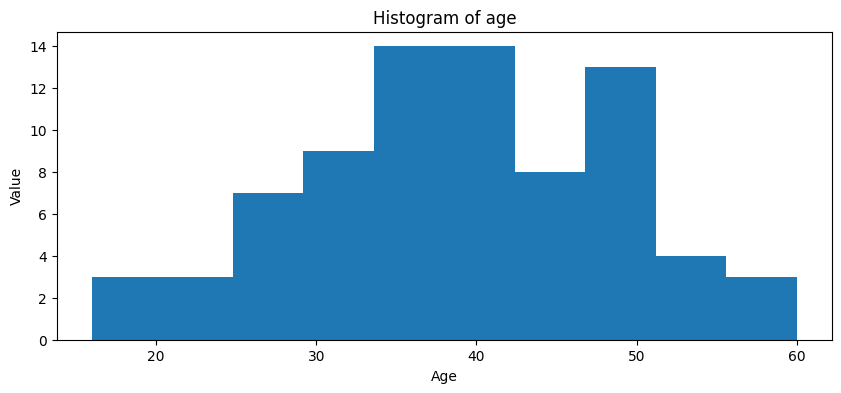

In [236]:
fig = plt.figure(figsize=(10,4))

plt.hist(df['Age'])
plt.title('Histogram of age')

plt.xlabel('Age')
plt.ylabel('Value')

plt.show()

The distribution is not a perfect example of a normal distribution, but we can assume that it is sufficiently 'normal'

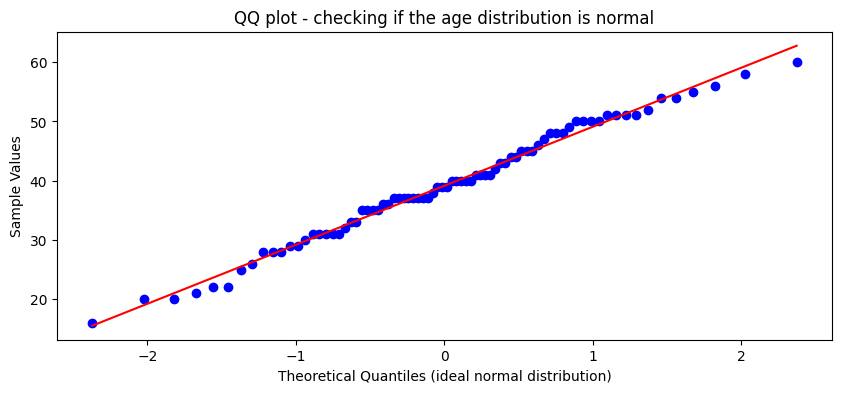

In [237]:
fig = plt.figure(figsize=(10,4))
stats.probplot(df['Age'], dist='norm', plot=plt)

plt.title('QQ plot - checking if the age distribution is normal')
plt.xlabel('Theoretical Quantiles (ideal normal distribution)')
plt.ylabel('Sample Values')

plt.show()

In [238]:
df['Age'].isna().sum()

np.int64(0)

The column does not contain empty values.

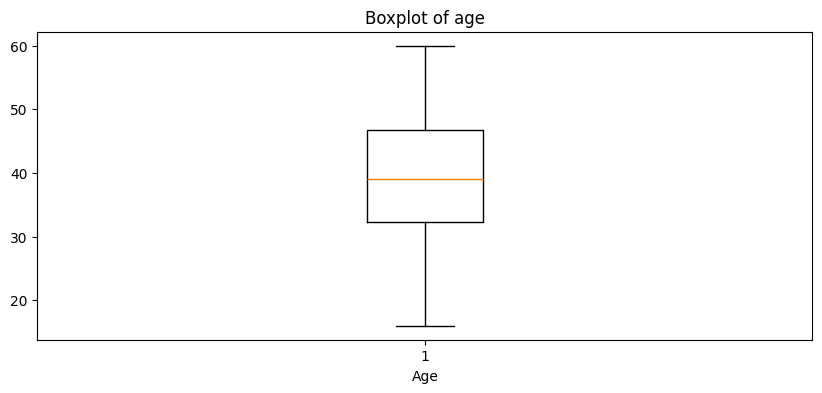

In [239]:
fig = plt.figure(figsize=(10,4))
plt.boxplot(df['Age'])

plt.title('Boxplot of age')
plt.xlabel('Age')

plt.show()

The column does not contain outliers.

## Gender

In [240]:
df['gender'].sample(5)

49    1
69    1
52    1
33    0
39    0
Name: gender, dtype: object

In [241]:
df['gender'].unique()

array([' ', '0', '1'], dtype=object)

We have values 0 and 1, but we don’t know which one represents men or women. There are also empty strings (missing values).

In [242]:
df['gender'].value_counts()

gender
0    43
1    33
      2
Name: count, dtype: int64

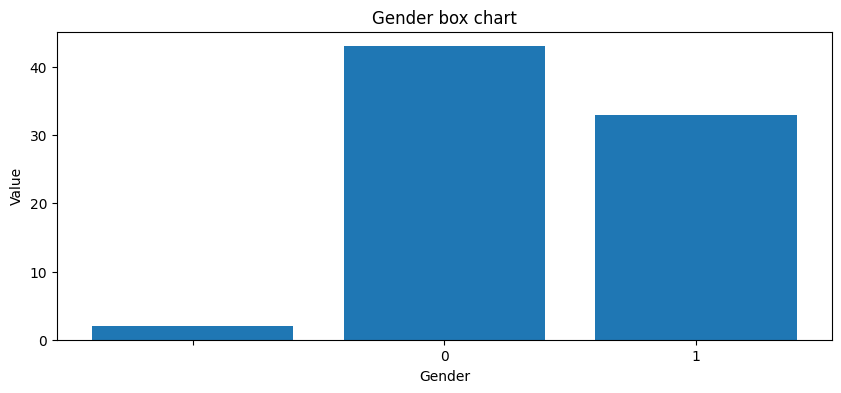

In [243]:
value, counts = np.unique(df['gender'], return_counts=True)
fig = plt.figure(figsize=(10,4))
plt.bar(value, counts)

plt.title('Gender box chart')
plt.xlabel('Gender')
plt.ylabel('Value')

plt.show()

In [244]:
counts = df['gender'].value_counts()
percentages = (df['gender'].value_counts(normalize=True) * 100 ).round(2)

result = pd.concat([counts,percentages], axis=1)
result.columns =['Amount','Percentage (%)']

result


,Amount,Percentage (%)
gender,,
0,43,55.13
1,33,42.31
,2,2.56


## Height

In [245]:
df['Height'].sample(5)

27    167
2     159
25    163
41    171
15    167
Name: Height, dtype: int64

In [246]:
df['Height'].describe()

count     78.000000
mean     170.820513
std       11.276621
min      141.000000
25%      164.250000
50%      169.500000
75%      174.750000
max      201.000000
Name: Height, dtype: float64

* The tallest person is 201 cm.
* The shortest person is 141 cm.
* On average, a person is 170 cm tall.

In [247]:
print("Mean", df['Height'].mean())
print("Median", df['Height'].median())

Mean 170.82051282051282
Median 169.5


The mean and median are similar; maybe the distribution is normal?

In [248]:
print("Kurtosis:",stats.kurtosis(df['Height']))
print("Skewness:",stats.skew(df['Height']))

Kurtosis: 0.7856260168567233
Skewness: 0.6882176548173298


The distribution is moderately right-skewed and leptokurtic.

In [249]:
df['Height'].isna().sum()

np.int64(0)

The are no empty values.

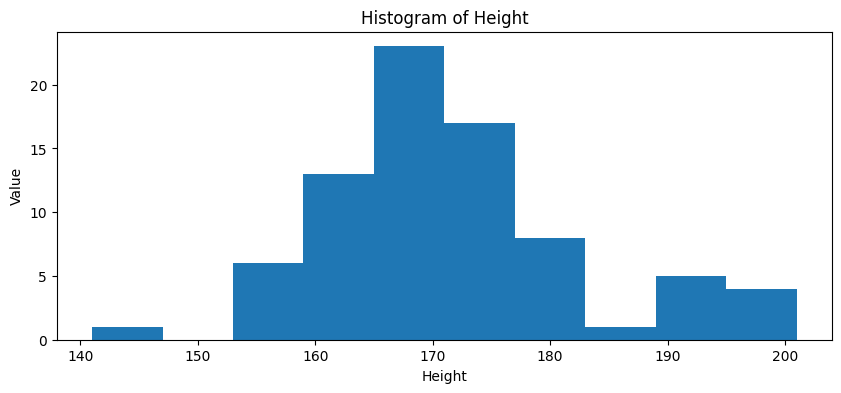

In [250]:
fig = plt.figure(figsize=(10,4))

plt.hist(df['Height'])
plt.title('Histogram of Height')

plt.xlabel('Height')
plt.ylabel('Value')

plt.show()

The distribution is not a perfect example of a normal distribution, but we can assume that it is sufficiently 'normal'

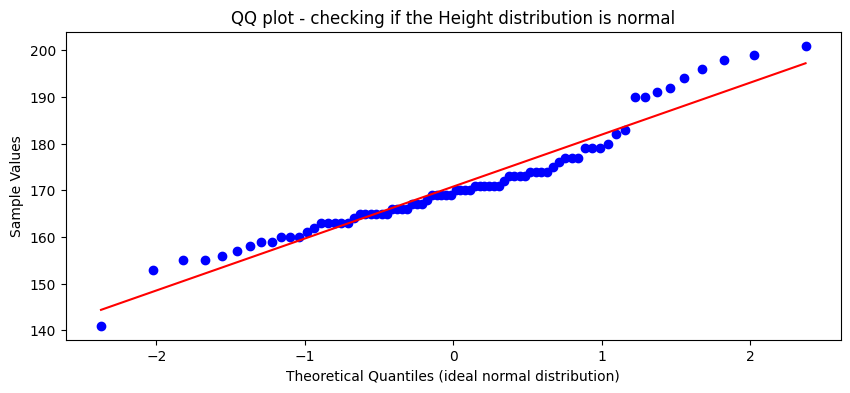

In [251]:
fig = plt.figure(figsize=(10,4))
stats.probplot(df['Height'], dist='norm', plot=plt)

plt.title('QQ plot - checking if the Height distribution is normal')
plt.xlabel('Theoretical Quantiles (ideal normal distribution)')
plt.ylabel('Sample Values')

plt.show()

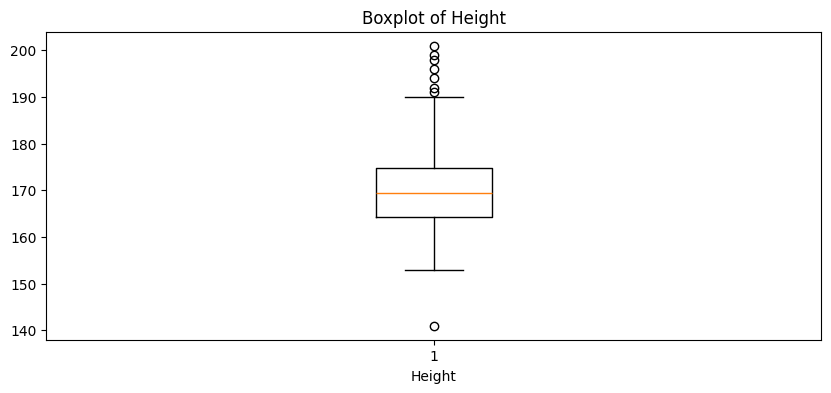

In [252]:
fig = plt.figure(figsize=(10,4))
plt.boxplot(df['Height'])

plt.title('Boxplot of Height')
plt.xlabel('Height')

plt.show()

The column contains outliers!!

### Shapiro–Wilk Normality Test

Before choosing an appropriate statistical test, we need to verify whether the data follows a **normal distribution**. A common method for testing normality is the **Shapiro–Wilk test**, which is a **goodness-of-fit test** used to determine how well a sample fits a normal distribution.

The **Shapiro–Wilk test** evaluates whether a sample comes from a normally distributed population. It compares the ordered observations of the sample with the expected structure of order statistics from a normal distribution.

**Formally:**

* **Null hypothesis ($H_0$):** The sample comes from a normally distributed population.

* **Alternative hypothesis ($H_1$):** The sample does not come from a normally distributed population.

* **Test statistic ($W$):**

$$
W =
\frac{
\left(
\sum_{i=1}^{\lfloor n/2 \rfloor}
a_{i,n}
\left(
x_{(n-i+1)} - x_{(i)}
\right)
\right)^2
}
{
\sum_{i=1}^{n} (x_i - \bar{x})^2
}
$$

where:

- $x_{(i)}$ are the ordered sample values (order statistics),
- $x_{(n-i+1)}$ are the symmetric ordered values from the opposite end of the sample,
- $\bar{x}$ is the sample mean,
- $a_{i,n}$ are constants derived from expected values of order statistics of a normal distribution,
- $n$ is the sample size.

The resulting **W statistic** is used to compute the **p-value**. If the p-value is smaller than the chosen significance level (e.g. $\alpha = 0.05$), we reject the null hypothesis and conclude that the data is **not normally distributed**.

In [253]:
def shapiro_normality_test(df, alpha = 0.05):
    stat, p_value = shapiro(df)

    print(f"Shapiro-Wilk test statistic: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value > alpha:
        print("Fail to reject H0 – the distribution can be considered normal")
    else:
        print("Reject H0 – the distribution is not normal")

In [254]:
shapiro_normality_test(df['Height'])

Shapiro-Wilk test statistic: 0.9433
p-value: 0.0017
Reject H0 – the distribution is not normal


The **Shapiro–Wilk Normality test (Goodness of Fit)** indicates that our distribution is not normal.

<span style="color:red"> Genders are labeled as 0 and 1, but we don’t know which corresponds to men or women. We will use hypothesis tests on average heights, leveraging the general fact that men are taller and historical data, and since height is not normally distributed, we will apply non-parametric tests to determine gender based on height. </span>

### Mann-Whitney U Test

Since we know that males are on average taller than females, we would normally use a one-sided independent **t-test** to check if the male average height is higher. However, because the **Shapiro–Wilk test** showed that height is not normally distributed, we will instead use the **Mann–Whitney U test**.

The **Mann–Whitney U test** is a non-parametric test for comparing two independent groups. Unlike a t-test, it does not compare means, but evaluates whether observations in one group tend to be larger (or smaller) than in the other group. The test works by ranking all observations together, then calculating the sum of ranks for each group. The U statistic is computed from these ranks and used to test the null hypothesis that the two groups come from the same distribution.

**Formally:**

* **Null hypothesis ($H_0$):** The probability that a randomly selected observation from group 1 is greater than a randomly selected observation from group 2 equals 0.5.

* **Alternative hypothesis ($H_1$):** Observations in group 1 tend to be larger (or smaller) than observations in group 2.

* **U statistic formula** (for group 1 of size $n_1$ and group 2 of size $n_2$):

$$
U_1 = n_1 n_2 + \frac{n_1 (n_1 + 1)}{2} - R_1
$$

where $R_1$ is the sum of ranks in group 1.

Similarly:

$$
U_2 = n_1 n_2 - U_1
$$

The smaller value of $U_1$ and $U_2$ is used to determine the p-value.



In [255]:
df.head()

,Person,gender,Age,Height,pre.weight,Diet,weight6weeks
0,25,,41,171,60,2,60.0
1,26,,32,174,103,2,103.0
2,1,0,22,159,58,1,54.2
3,2,0,46,192,60,1,54.0
4,3,0,55,170,64,1,63.3


In [256]:
avg_height = df.groupby('gender')['Height'].mean()
avg_height.head()

gender
     172.500000
0    167.348837
1    175.242424
Name: Height, dtype: float64

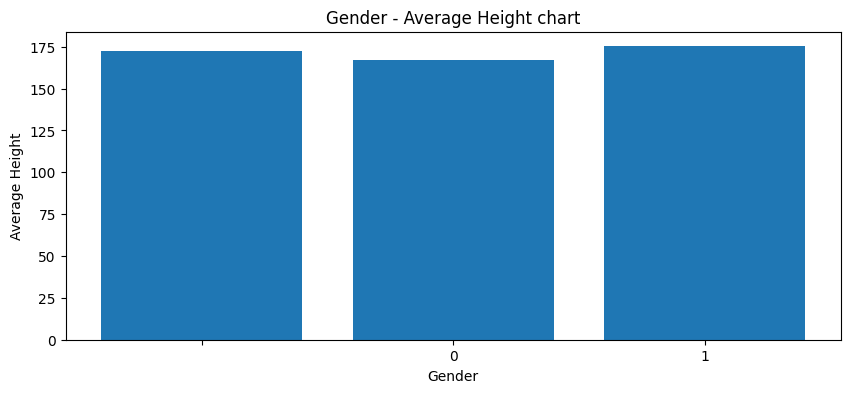

In [257]:
fig = plt.figure(figsize=(10,4))
plt.bar(avg_height.index, avg_height.values)

plt.title('Gender - Average Height chart')
plt.xlabel('Gender')
plt.ylabel('Average Height')

plt.show()

From the bar chart results, category **1** has a higher average height. Therefore, we can assume that observations in group 1 tend to be higher than those in group 0.

In [258]:
group0 = df[df['gender'] == '0']['Height']
group0.sample(5)

40    170
13    156
11    165
14    163
27    167
Name: Height, dtype: int64

In [259]:
group1 = df[df['gender'] == '1']['Height']
group1.sample(5)

66    155
72    179
73    183
53    166
65    182
Name: Height, dtype: int64

In [260]:
alpha = 0.05
stat, p_value = mannwhitneyu(group1, group0, alternative='greater')

print(f"Mann-Whitney U test statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value > alpha:
    print("Fail to reject H₀ – There is no evidence that a randomly chosen sample from group 1 has higher values than one from group 0.")
else:
    print("Reject H₀ – Group 1 tends to have higher values than group 0.")

Mann-Whitney U test statistic: 971.5000
p-value: 0.0030
Reject H₀ – Group 1 tends to have higher values than group 0.


After the Mann-Whitney test, we can assume that 1 corresponds to males and 0 to females.

In Poland, men are on average 177.3 cm tall, and women 164.6 cm. We will compare the average heights in our sample to these historical values to see if our data differ significantly from the population norms.


### Wilcoxon Signed-Rank Test

To compare the average height in our sample with historical values in Poland (177.3 cm for males, 164.6 cm for females), we would normally use a **one-sample t-test**. However, since the **Shapiro–Wilk test** showed that height is not normally distributed, we instead use the **Wilcoxon signed-rank test**.

The **Wilcoxon signed-rank test** is a non-parametric test for paired or one-sample data. Unlike a t-test, it does not directly compare means, but evaluates whether the differences between observations and a reference value (or between paired observations) tend to be positive or negative. The test works by ranking the absolute values of differences, then summing ranks separately for positive and negative differences. The smaller of these sums is used as the test statistic to assess whether the median difference is zero.

**Formally:**

* **Null hypothesis ($H_0$):** The median of the differences between observations and the reference value equals $0$.

* **Alternative hypothesis ($H_1$):** The median of the differences is not $0$ (differences tend to be positive or negative).

* **Test statistic formula:**

$$
W^+ = \sum_{d_i > 0} R_i, \quad W^- = \sum_{d_i < 0} R_i
$$

$$
W = \min(W^+, W^-)
$$

where $d_i$ are the differences between observations and the reference value (or between paired observations), and $R_i$ are the ranks of $|d_i|$.

The smaller value of $W^+$ and $W^-$ is used to determine the p-value.

In [261]:
# Historical Values
reference_values = {'0': 164.6, '1': 177.3}

alpha = 0.05

for gender in ['0', '1']:

    sample = df[df['gender'] == gender]['Height']
    reference_value = reference_values[gender]

    differences = [x - reference_value for x in sample]

    stat, p_value = wilcoxon(differences)

    gender_name = 'Female' if gender == '0' else 'Male'
    print(f"{gender_name}: Wilcoxon statistic = {stat:.4}, p-value = {p_value:.4}")

    if p_value > alpha:
        print(f"Fail to reject H₀: No evidence that the median height differs from {reference_value} cm.\n")
    else:
        print(f"Reject H₀: Median height is significantly different from {reference_value} cm.\n")

Female: Wilcoxon statistic = 299.0, p-value = 0.03551
Reject H₀: Median height is significantly different from 164.6 cm.

Male: Wilcoxon statistic = 228.0, p-value = 0.3481
Fail to reject H₀: No evidence that the median height differs from 177.3 cm.



## pre.weight

In [262]:
df['pre.weight'].sample(5)

20    62
23    63
6     65
48    78
24    65
Name: pre.weight, dtype: int64

In [263]:
df['pre.weight'].describe()

count     78.000000
mean      72.525641
std        8.723344
min       58.000000
25%       66.000000
50%       72.000000
75%       78.000000
max      103.000000
Name: pre.weight, dtype: float64

* The heaviest person before the diet weighed 103 kg.
* The lightest person before the diet weighed 58 kg.
* On average, a person weighed 72 kg before the diet.

In [264]:
print('Mean', np.mean(df['pre.weight']))
print('Median', np.median(df['pre.weight']))

Mean 72.52564102564102
Median 72.0


Mean and median are similar. Maybe distribution is normal?

In [265]:
print("Kurtosis:",stats.kurtosis(df['pre.weight']))
print("Skewness:",stats.skew(df['pre.weight']))

Kurtosis: 0.4796236428282734
Skewness: 0.5024639581928805


* The distribution is almost symmetric, with a slight positive skew.
* The kurtosis is slightly above zero, so we can say it is mesokurtic.



In [266]:
df['pre.weight'].isna().sum()

np.int64(0)

There are no missing values

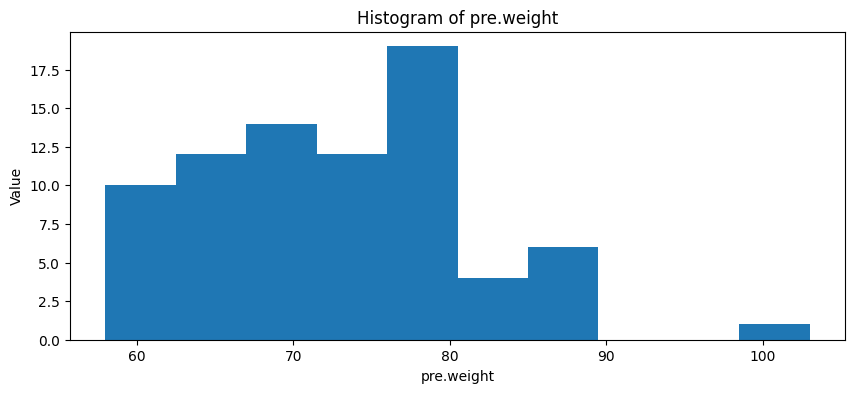

In [267]:
fig = plt.figure(figsize=(10,4))

plt.hist(df['pre.weight'])
plt.title('Histogram of pre.weight')

plt.xlabel('pre.weight')
plt.ylabel('Value')

plt.show()

Visually distribution is not normal

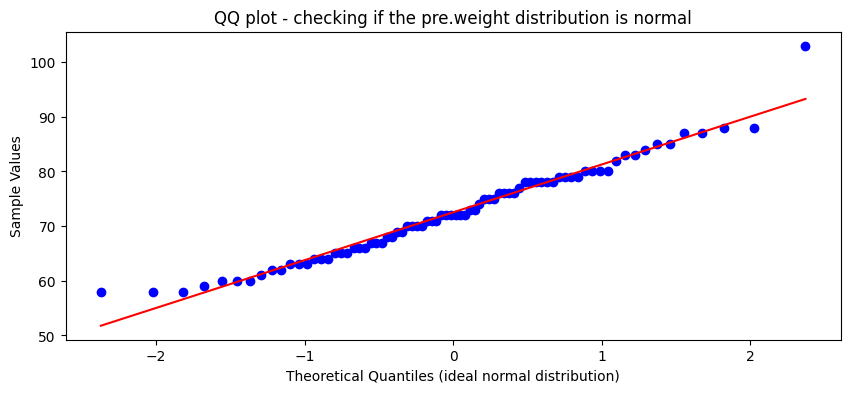

In [268]:
fig = plt.figure(figsize=(10,4))
stats.probplot(df['pre.weight'], dist='norm', plot=plt)

plt.title('QQ plot - checking if the pre.weight distribution is normal')
plt.xlabel('Theoretical Quantiles (ideal normal distribution)')
plt.ylabel('Sample Values')

plt.show()

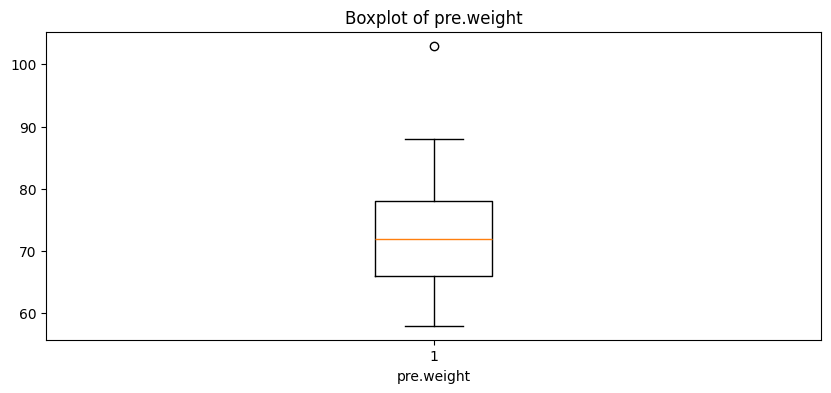

In [269]:
fig = plt.figure(figsize=(10,4))
plt.boxplot(df['pre.weight'])

plt.title('Boxplot of pre.weight')
plt.xlabel('pre.weight')

plt.show()

Column contains outliers.

### Shapiro-Wilk normality test

- **H0**: The data is normally distributed 
- **HA**: The data is **not normally distributed**

In [270]:
shapiro_normality_test(df['pre.weight'])

Shapiro-Wilk test statistic: 0.9692
p-value: 0.0554
Fail to reject H0 – the distribution can be considered normal


After performing the test, we can assume that the distribution is normal.

## weight6weeks

In [271]:
df['weight6weeks'].sample(5)

66    68.5
58    72.5
33    58.2
9     60.5
69    77.5
Name: weight6weeks, dtype: float64

In [272]:
df['weight6weeks'].describe()

count     78.000000
mean      68.680769
std        8.924504
min       53.000000
25%       61.850000
50%       68.950000
75%       73.825000
max      103.000000
Name: weight6weeks, dtype: float64

- The heaviest person after the diet weighed 103 kg.
- The lightest person before the diet weighed 58 kg.
- On average, a person weighed 68 kg.

In [273]:
print('Mean', np.mean(df['weight6weeks']))
print('Median', np.median(df['weight6weeks']))

Mean 68.68076923076923
Median 68.95


Mean and median are similar. Maybe distribution is normal?

In [274]:
print("Kurtosis:",stats.kurtosis(df['weight6weeks']))
print("Skewness:",stats.skew(df['weight6weeks']))

Kurtosis: 1.2265134589638853
Skewness: 0.6601099761662811


- The distribution is slightly positively skewed.
- The kurtosis is above zero, so we can say it is leptokurtic.

In [275]:
df['weight6weeks'].isna().sum()

np.int64(0)

There are no missing values

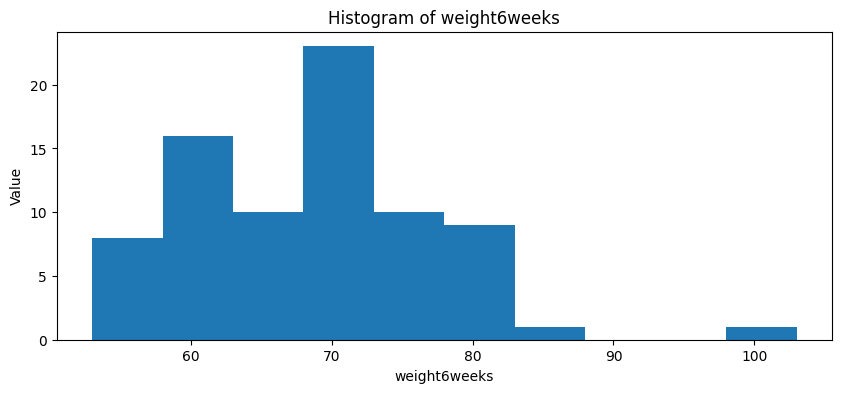

In [276]:
fig = plt.figure(figsize=(10,4))

plt.hist(df['weight6weeks'])
plt.title('Histogram of weight6weeks')

plt.xlabel('weight6weeks')
plt.ylabel('Value')

plt.show()

Visually distribution is not normal

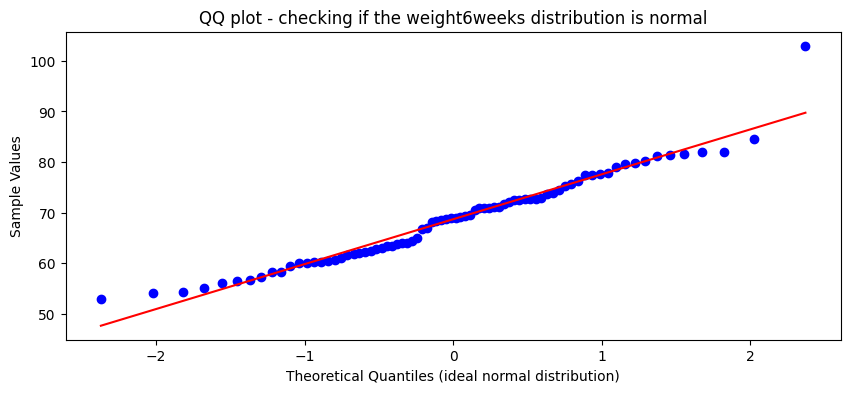

In [277]:
fig = plt.figure(figsize=(10,4))
stats.probplot(df['weight6weeks'], dist='norm', plot=plt)

plt.title('QQ plot - checking if the weight6weeks distribution is normal')
plt.xlabel('Theoretical Quantiles (ideal normal distribution)')
plt.ylabel('Sample Values')

plt.show()

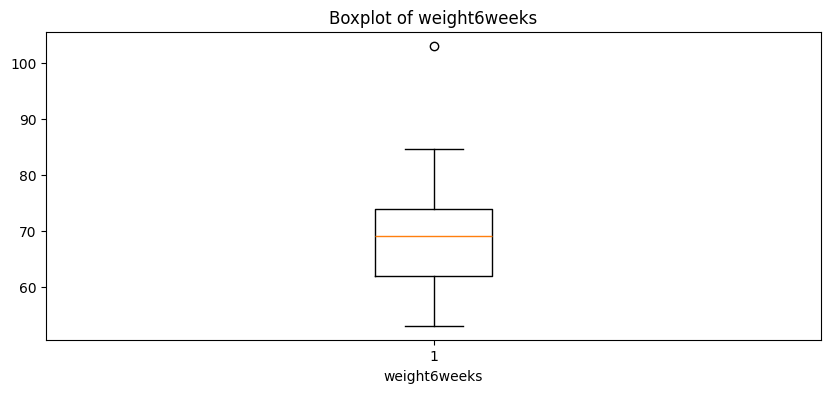

In [278]:
fig = plt.figure(figsize=(10,4))
plt.boxplot(df['weight6weeks'])

plt.title('Boxplot of weight6weeks')
plt.xlabel('weight6weeks')

plt.show()

Column contains outliers.

### Shapiro-Wilk normality test

- **H0**: The data is normally distributed 
- **HA**: The data is **not normally distributed**

In [279]:
shapiro_normality_test(df['weight6weeks'])

Shapiro-Wilk test statistic: 0.9580
p-value: 0.0115
Reject H0 – the distribution is not normal


---------------------

### Diet effectiveness test

### Paired t-test (dependent samples t-test)

**Purpose:**
The paired t-test is used to compare the means of two related groups, e.g., measurements of the same subjects **before and after an intervention**. It helps determine if the change between measurements is statistically significant.

**When to use:**
- Data are numerical and continuous.
- Measurements are **paired**: the same subjects measured twice (before/after) or matched pairs.
- Examples: weight before and after a diet, blood sugar levels before and after treatment, reaction times before and after training.

**Hypotheses:**
- **H₀ (null hypothesis):** The mean difference between pairs $= 0$
- **H₁ (alternative hypothesis):** The mean difference $\neq 0$ (two-sided) or $>0 / <0$ (one-sided if directional)

**How it works:**
1. Compute differences for each pair:
   $D_i = X_{\text{after},i} - X_{\text{before},i}$
2. Check the **normality of differences $D$** (Shapiro-Wilk test or Q-Q plot).
3. If differences are approximately normal, calculate the t-statistic:

$$t = \frac{\bar{D}}{s_D / \sqrt{n}}$$

Where:
- $\bar{D}$ = mean difference
- $s_D$ = standard deviation of differences
- $n$ = number of pairs

4. Compare $t$ with the t-distribution with $n-1$ degrees of freedom to get the **p-value**.

**Assumptions:**
- Pairs are independent of each other.
- Differences $D$ are normally distributed.
- Data are at least interval scale.

**Alternative if assumptions are violated:**
- If differences are not normal → use the **paired Wilcoxon test** (non-parametric test for dependent samples).




We will check whether the diets people tried were effective.

The difference in weight before and after the diet is equal to 0 → the diet is not effective; otherwise, the diet is effective.

m - mean difference between pre and after diet weight

- H0: m = m0 = 0 - Diet has no effect
- HA: m ≠ m0 ≠ 0 - Diet has an effect

<b> We will consider using Paired t-test (when weight difference distribution is normal). </b>

In [280]:
df['weight_diff'] = df['pre.weight'] - df['weight6weeks']

Normality check

- **H0**: The data is normally distributed 
- **HA**: The data is **not normally distributed**

In [281]:
shapiro_normality_test(df['weight_diff'])

Shapiro-Wilk test statistic: 0.9899
p-value: 0.8020
Fail to reject H0 – the distribution can be considered normal


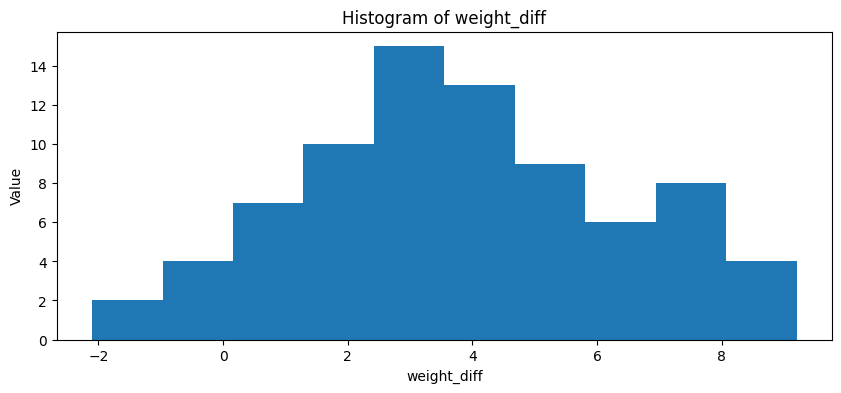

In [282]:
fig = plt.figure(figsize=(10,4))

plt.hist(df['weight_diff'])
plt.title('Histogram of weight_diff')

plt.xlabel('weight_diff')
plt.ylabel('Value')

plt.show()

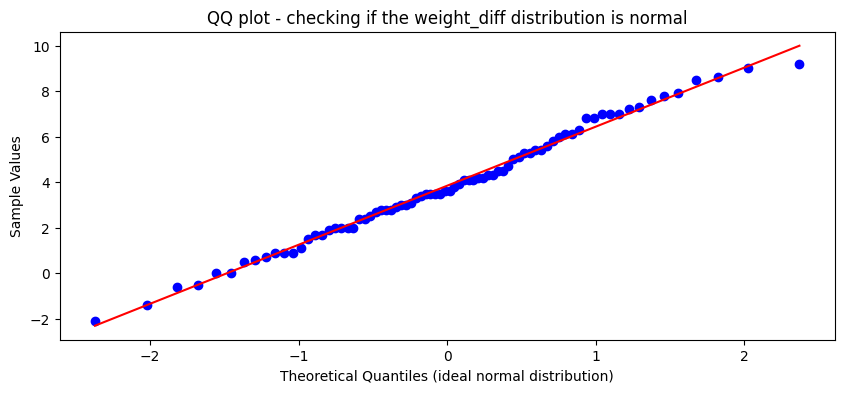

In [283]:
fig = plt.figure(figsize=(10,4))
stats.probplot(df['weight_diff'], dist='norm', plot=plt)

plt.title('QQ plot - checking if the weight_diff distribution is normal')
plt.xlabel('Theoretical Quantiles (ideal normal distribution)')
plt.ylabel('Sample Values')

plt.show()

We can assume that distribution is normal

In [284]:
t_stat, p_value = stats.ttest_rel(df['pre.weight'], df['weight6weeks'])

In [285]:
if p_value < alpha:
    print("Reject H0 → Diet has a significant effect on weight")
else:
    print("Fail to reject H0 → Diet does not have a significant effect on weight")

Reject H0 → Diet has a significant effect on weight


We assume that trying no matter which diet is effective

## Diet

In [286]:
df['Diet'].sample(5)

63    2
0     2
9     1
38    3
76    3
Name: Diet, dtype: int64

In [287]:
df['Diet'].unique()

array([2, 1, 3])

We have 3 types of diet

In [288]:
df['Diet'].value_counts()

Diet
2    27
3    27
1    24
Name: count, dtype: int64

In [289]:
df['Diet'].isna().sum()

np.int64(0)

We don't have missing values

### Diet effectiveness comparision

We will group people by diets they were following  and for each group we will test:

m - mean difference between pre and after diet weight

- H0: m = m0 = 0 - Diet has no effect
- HA: m ≠ m0 ≠ 0 - Diet has an effect

<b> We will consider using Paired t-test (when weight difference distribution is normal). </b>

Normality check

- **H0**: The data is normally distributed 
- **HA**: The data is **not normally distributed**


--------DIET TYPE: 2----

Mean: 3.03
Median: 3.30

Shapiro-Wilk test statistic: 0.9856
p-value: 0.9612
Fail to reject H0 – the distribution can be considered normal


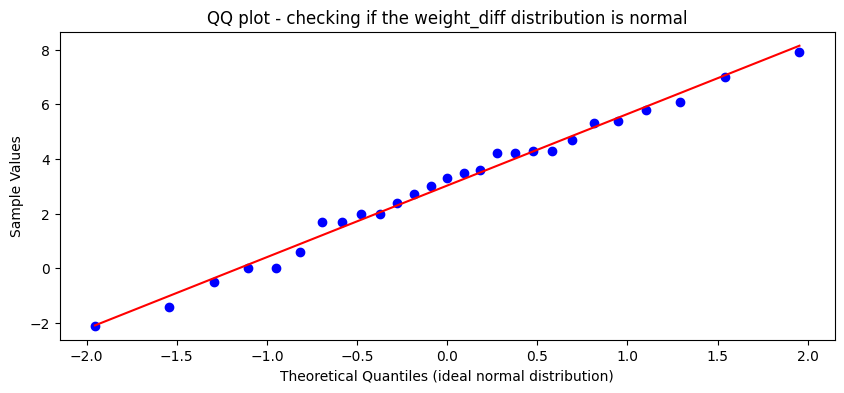


--------DIET TYPE: 1----

Mean: 3.30
Median: 3.05

Shapiro-Wilk test statistic: 0.9255
p-value: 0.0775
Fail to reject H0 – the distribution can be considered normal


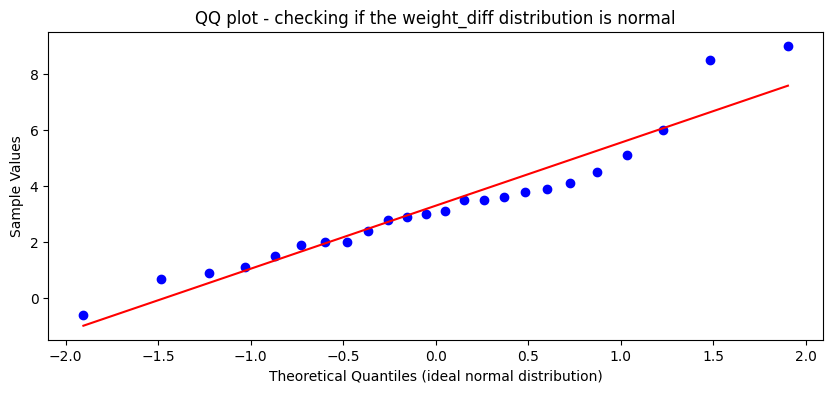


--------DIET TYPE: 3----

Mean: 5.15
Median: 5.40

Shapiro-Wilk test statistic: 0.9601
p-value: 0.3720
Fail to reject H0 – the distribution can be considered normal


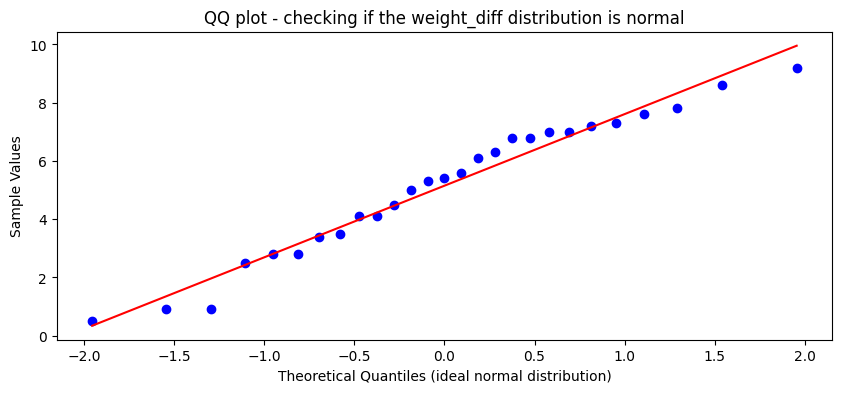

In [290]:
for diet_type in df['Diet'].unique():
    df_by_diet_type = df[df['Diet']==diet_type]
    print(f"\n--------DIET TYPE: {diet_type}----\n")

    print(f"Mean: {np.mean(df_by_diet_type['weight_diff']):.2f}")
    print(f"Median: {np.median(df_by_diet_type['weight_diff']):.2f}\n")

    shapiro_normality_test(df_by_diet_type['weight_diff'])

    fig = plt.figure(figsize=(10,4))
    stats.probplot(df_by_diet_type['weight_diff'], dist='norm', plot=plt)

    plt.title('QQ plot - checking if the weight_diff distribution is normal')
    plt.xlabel('Theoretical Quantiles (ideal normal distribution)')
    plt.ylabel('Sample Values')

    plt.show()

All distribution are normal. We can use Paired t-test.

In [291]:
for diet_type in df['Diet'].unique():
    df_by_diet_type = df[df['Diet']==diet_type]
    
    t_stat, p_val = stats.ttest_rel(df_by_diet_type['pre.weight'], df_by_diet_type['weight6weeks'])

    print(f"\n--------DIET TYPE: {diet_type}----\n")

    print(f"Mean diff {np.mean(df_by_diet_type['weight_diff']):.2f}")
    print(f"p-value = {p_value:.4f}")

    if p_value < alpha:
        print("Reject H0 → Diet has a significant effect on weight")
    else:
        print("Fail to reject H0 → Diet does not have a significant effect on weight")


--------DIET TYPE: 2----

Mean diff 3.03
p-value = 0.0000
Reject H0 → Diet has a significant effect on weight

--------DIET TYPE: 1----

Mean diff 3.30
p-value = 0.0000
Reject H0 → Diet has a significant effect on weight

--------DIET TYPE: 3----

Mean diff 5.15
p-value = 0.0000
Reject H0 → Diet has a significant effect on weight
